# Resumen y Explicación — Regresión Logística
## Teoría de la clase + explicación línea por línea del práctico "Beca por Participación"

> Este documento junta dos cosas: (1) la teoría de la clase de Regresión Logística (Módulo 2, Unidad 4) y (2) una explicación de **cada línea de código** del práctico `Practico_Regresion_Logistica_Beca_Participacion.ipynb`, con el motivo por el cual se escribió así.


---
# Parte 1 — Teoría: Regresión Logística

## 1.1 ¿Por qué no alcanza con una regresión lineal para clasificar?

La regresión logística **no predice un número continuo** (como el precio de una casa). Predice la **probabilidad** de que algo pertenezca a una clase (0 o 1).

**El problema de usar una recta (regresión lineal) para esto:**

```
Regresión Lineal                    Regresión Logística

1 ┤    ●●●●●●●  ⚠ predicción         1 ┤          ●●●●●●●●●
  │  ●●●        150%  (imposible)      │      ╱‾‾‾
  │●●                                  │    ╱
0 ┤●● ⚠ predicción -20% (imposible)  0 ┤●●●●
  └──────────────────────────          └──────────────────────
```

- La recta genera valores sin límite (de -∞ a +∞) → puede "predecir" cosas absurdas como -20% o 150% de probabilidad.
- La regresión logística **aplasta** cualquier valor real para que caiga siempre entre 0 y 1, usando la función sigmoide (ver 1.2).

| | Regresión Lineal | Regresión Logística |
|---|---|---|
| Salida | Valores continuos sin límite | Probabilidades acotadas (0 a 1) |
| Uso principal | Predicción numérica (precios, clima) | Clasificación binaria (beca sí/no, fraude, spam) |
| Sensibilidad a outliers | Muy sensible (mínimos cuadrados) | Más robusta (la sigmoide acota el impacto) |


## 1.2 El motor de transformación: la función sigmoide

El modelo funciona en dos pasos:

**Paso 1 — Combinación lineal (igual que en regresión lineal):**
$$z = \beta_0 + \beta_1 x$$

Esto da un número cualquiera, de -∞ a +∞ (por eso solo, no sirve como probabilidad).

**Paso 2 — Función sigmoide:** convierte ese número en una probabilidad entre 0 y 1.
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Si `z` es muy grande y positivo → `σ(z) ≈ 1`
- Si `z` es muy grande y negativo → `σ(z) ≈ 0`
- Si `z = 0` → `σ(z) = 0.5`

Esa forma de "S" es la curva característica de la regresión logística.


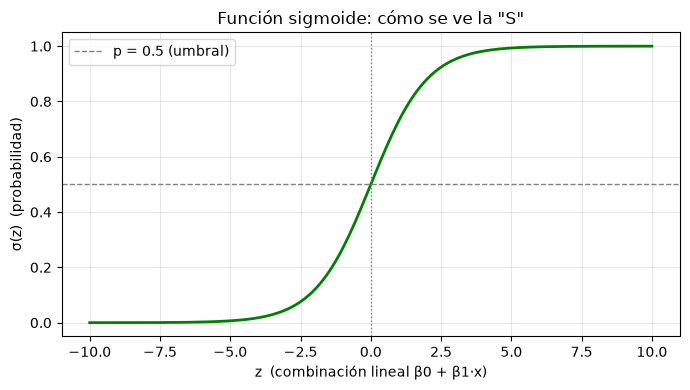

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoide(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
p = sigmoide(z)

plt.figure(figsize=(7, 4))
plt.plot(z, p, color='green', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='p = 0.5 (umbral)')
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.xlabel('z  (combinación lineal β0 + β1·x)')
plt.ylabel('σ(z)  (probabilidad)')
plt.title('Función sigmoide: cómo se ve la "S"')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 1.3 El umbral: de la probabilidad a la decisión

La sigmoide da un número continuo (ej: 0.98), pero al final hay que decidir 0 o 1. Para eso se usa un **umbral**, que por defecto es **0.5**:

- Si `probabilidad >= 0.5` → se predice clase **1**
- Si `probabilidad < 0.5` → se predice clase **0**

Este es exactamente el criterio que usa `modelo.predict()` internamente (a diferencia de `modelo.predict_proba()`, que devuelve el número crudo sin aplicar el corte).

**El umbral se puede ajustar según el negocio.** Por ejemplo, en un diagnóstico médico de alto riesgo conviene bajar el umbral a 0.3 para no dejar pasar enfermos (aunque eso genere más falsas alarmas).


## 1.4 Matriz de confusión

Es la tabla que compara lo que el modelo **predijo** contra lo que **realmente pasó**. En un problema binario tiene 4 casillas:

|                    | Predijo 0 (No)            | Predijo 1 (Sí)             |
|--------------------|----------------------------|------------------------------|
| **Real = 0 (No)**  | Verdadero Negativo (TN)   | Falso Positivo (FP)         |
| **Real = 1 (Sí)**  | Falso Negativo (FN)       | Verdadero Positivo (TP)     |

**¿Por qué no alcanza con mirar solo el % de aciertos (accuracy)?**
Si una clase es muy rara (ej: una enfermedad que afecta al 1%), un modelo que siempre responde "sano" tiene 99% de accuracy y es completamente inútil. Por eso conviene mirar precision y recall por separado.


## 1.5 Las 4 métricas de evaluación

Con base en TP, FP, FN y TN se calculan estas 4 métricas:

| Métrica | Fórmula | ¿Qué responde? | ¿Cuándo priorizarla? |
|---|---|---|---|
| **Accuracy** | `(TP+TN) / Total` | ¿Qué % de las predicciones fueron correctas en general? | Cuando las clases están equilibradas |
| **Precision** | `TP / (TP+FP)` | De todo lo que predije como positivo, ¿cuánto lo era realmente? | Cuando molesta más un falso positivo (ej: acusar a alguien sano de estar enfermo) |
| **Recall (sensibilidad)** | `TP / (TP+FN)` | De todos los positivos reales, ¿cuántos detecté? | Cuando molesta más un falso negativo (ej: no detectar una enfermedad) |
| **F1-score** | `2 · (Precision·Recall) / (Precision+Recall)` | Balance entre precision y recall | Cuando ambas importan o las clases están desbalanceadas |

**Ejemplo numérico (caso de un modelo médico, de la teoría de la clase):**


In [2]:
# Ejemplo de la teoría: un modelo médico evaluado sobre 100 pacientes
TP, FP, FN, TN = 50, 5, 10, 35   # 50 enfermos detectados, 5 falsas alarmas, 10 enfermos no detectados, 35 sanos correctos

accuracy  = (TP + TN) / (TP + FP + FN + TN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f'Accuracy  = {accuracy:.2f}  → el modelo acierta el {accuracy:.0%} de las veces en general')
print(f'Precision = {precision:.2f}  → cuando dice "enfermo", acierta el {precision:.0%} de las veces')
print(f'Recall    = {recall:.2f}  → detecta al {recall:.0%} de los enfermos reales (se le escapan 10)')
print(f'F1-score  = {f1:.2f}  → balance general entre precision y recall')


Accuracy  = 0.85  → el modelo acierta el 85% de las veces en general
Precision = 0.91  → cuando dice "enfermo", acierta el 91% de las veces
Recall    = 0.83  → detecta al 83% de los enfermos reales (se le escapan 10)
F1-score  = 0.87  → balance general entre precision y recall


---
# Parte 2 — Explicación línea por línea del práctico

El práctico entrena un modelo de regresión logística para predecir si un estudiante recibe una beca (`1`) o no (`0`) según su **porcentaje de participación** en actividades extracurriculares, usando el archivo `participacion_beca.csv` (10 estudiantes).

A continuación, cada celda del práctico, con el código tal cual quedó y una tabla explicando qué hace cada línea y por qué.

## 2.1 Importar librerías

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score,
                              f1_score, classification_report)
```

| Línea | Qué hace | Por qué se necesita acá |
|---|---|---|
| `import pandas as pd` | Librería para manejar datos en tablas (DataFrames) | Para leer el CSV y manipular las columnas |
| `import numpy as np` | Cálculo numérico | Se usa `np.linspace` para generar los puntos de la curva logística |
| `import matplotlib.pyplot as plt` | Gráficos | Para el scatter inicial y la curva logística |
| `import seaborn as sns` | Gráficos estadísticos sobre matplotlib | Para dibujar la matriz de confusión como heatmap |
| `from sklearn.linear_model import LogisticRegression` | Trae la clase del modelo | Es el algoritmo que se entrena |
| `from sklearn.metrics import (...)` | Trae las funciones de evaluación | `confusion_matrix`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report` se usan todas en la última celda |


## 2.2 Cargar los datos

```python
ruta = 'participacion_beca.csv'
df = pd.read_csv(ruta)
df
```

| Línea | Qué hace |
|---|---|
| `ruta = 'participacion_beca.csv'` | Nombre del archivo. Al ser una ruta **relativa**, Python lo busca en la misma carpeta donde está el notebook — por eso el CSV tiene que estar junto al `.ipynb` |
| `df = pd.read_csv(ruta)` | Lee el CSV y lo convierte en un DataFrame de pandas |
| `df` | Al ser la última línea de la celda, Jupyter la imprime automáticamente — muestra la tabla completa (10 filas: `Participación (%)` y `Beca otorgada`) |


## 2.3 Visualización inicial

```python
plt.figure(figsize=(8, 5))
plt.scatter(df['Participación (%)'], df['Beca otorgada'], color='blue')
plt.xlabel('Participación (%)')
plt.ylabel('Beca otorgada (0 = No, 1 = Sí)')
plt.title('Participación vs Beca otorgada')
plt.grid(True)
plt.show()
```

**Por qué se agregó esta celda:** antes de entrenar cualquier modelo conviene *mirar los datos*. Acá se ve que hasta 20% nadie recibe la beca (0) y desde 25% todos la reciben (1) — un salto bastante limpio. Esto **justifica visualmente** por qué una curva en forma de S (sigmoide) tiene sentido para este problema, en vez de una recta.


## 2.4 Separar X e y

```python
X = df[['Participación (%)']]
y = df['Beca otorgada']
```

| Línea | Qué hace | Por qué |
|---|---|---|
| `X = df[['Participación (%)']]` | Selecciona la columna de entrada, pero con **doble corchete** | Scikit-learn exige que `X` sea una tabla 2D (filas × columnas), aunque haya una sola columna. `df[['col']]` devuelve un DataFrame; `df['col']` (un corchete) devolvería una Serie 1D y `modelo.fit()` fallaría |
| `y = df['Beca otorgada']` | Selecciona la columna objetivo, con **un solo corchete** | `y` sí puede ser 1D (una Serie): es la etiqueta que se quiere predecir |


## 2.5 Crear el modelo y entrenar

```python
modelo = LogisticRegression()
modelo.fit(X, y)
```

| Línea | Qué hace |
|---|---|
| `modelo = LogisticRegression()` | Crea el objeto del modelo, vacío, con los hiperparámetros por defecto (todavía no sabe nada de los datos) |
| `modelo.fit(X, y)` | Acá ocurre el entrenamiento: el algoritmo busca los coeficientes `β0` (intercepto) y `β1` (pendiente) que mejor separan las clases 0 y 1, maximizando la verosimilitud de los datos observados (no minimiza el error cuadrático como la regresión lineal) |

Después de `fit`, se puede inspeccionar qué aprendió el modelo:


In [3]:
# Celda autocontenida: repite el entrenamiento del práctico para poder
# inspeccionar los coeficientes aprendidos (no depende del otro notebook)
import pandas as pd
from sklearn.linear_model import LogisticRegression

df_demo = pd.read_csv('participacion_beca.csv')
X_demo = df_demo[['Participación (%)']]
y_demo = df_demo['Beca otorgada']

modelo_demo = LogisticRegression()
modelo_demo.fit(X_demo, y_demo)

print('Intercepto (β0):', modelo_demo.intercept_[0])
print('Coeficiente (β1):', modelo_demo.coef_[0][0])
print()
print('Interpretación: por cada punto que sube la participación (%),')
print('el log-odds de conseguir la beca aumenta en', round(modelo_demo.coef_[0][0], 3))


Intercepto (β0): -16.640602596897
Coeficiente (β1): 0.7395647556721735

Interpretación: por cada punto que sube la participación (%),
el log-odds de conseguir la beca aumenta en 0.74


## 2.6 Predecir

```python
nueva_participacion = pd.DataFrame({'Participación (%)': [28]})
proba = modelo.predict_proba(nueva_participacion)[:, 1][0]
prediccion = modelo.predict(nueva_participacion)[0]

print(f'Probabilidad estimada de obtener la beca: {proba:.2f}')
print('Predicción:', 'Beca otorgada' if prediccion == 1 else 'Beca no otorgada')
```

| Línea | Qué hace | Por qué |
|---|---|---|
| `nueva_participacion = pd.DataFrame({'Participación (%)': [28]})` | Arma un DataFrame de una sola fila con el mismo **nombre de columna** que se usó al entrenar `X` | Sklearn necesita que la entrada tenga la misma forma y nombres de columna que los datos de entrenamiento; si el nombre no coincide, tira error o warning |
| `modelo.predict_proba(nueva_participacion)` | Devuelve un array con **2 columnas**: `[probabilidad de clase 0, probabilidad de clase 1]` | Es la salida "cruda" de la sigmoide, sin aplicar el umbral |
| `[:, 1]` | Se queda con la segunda columna (probabilidad de clase 1 = "Sí beca") | Es la que nos interesa mostrar |
| `[0]` | Se queda con el primer (único) resultado, porque solo se predijo 1 fila | Convierte el array de 1 elemento en un número simple |
| `modelo.predict(nueva_participacion)[0]` | Aplica el umbral 0.5 automáticamente y devuelve directamente la clase (0 o 1) | Es el atajo cuando no interesa el número exacto de probabilidad, solo la decisión final |

**Resultado obtenido:** con 28% de participación, el modelo estima **98% de probabilidad** de obtener la beca → predicción: **Beca otorgada**. Tiene sentido: 28% ya está bien adentro de la zona donde, en los datos de entrenamiento, todos recibieron la beca (desde 25%).


## 2.7 Graficar la curva logística

```python
valores_x = np.linspace(df['Participación (%)'].min(), df['Participación (%)'].max(), 100)
valores_df = pd.DataFrame(valores_x, columns=['Participación (%)'])
probas = modelo.predict_proba(valores_df)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(df['Participación (%)'], df['Beca otorgada'], color='blue', label='Datos reales')
plt.plot(valores_x, probas, color='green', label='Curva logística')
plt.scatter([28], [proba], color='red', marker='x', s=100, label='Predicción (28%)')
plt.xlabel('Participación (%)')
plt.ylabel('Probabilidad de obtener beca')
plt.title('Modelo de regresión logística')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
```

| Línea | Qué hace | Por qué |
|---|---|---|
| `np.linspace(min, max, 100)` | Genera 100 valores equiespaciados entre el mínimo y el máximo de participación real | Con solo 10 puntos reales no se puede dibujar una curva suave; con 100 puntos artificiales sí |
| `valores_df = pd.DataFrame(...)` | Convierte ese array en un DataFrame con el mismo nombre de columna que espera el modelo | Igual que en la predicción del punto 2.6 |
| `modelo.predict_proba(valores_df)[:, 1]` | Calcula la probabilidad de "Sí beca" para cada uno de esos 100 valores | Esos 100 puntos, unidos, dibujan la forma de "S" de la sigmoide |
| `plt.scatter(...)` (azul) | Grafica los 10 datos reales | Para comparar el modelo contra la realidad |
| `plt.plot(valores_x, probas, ...)` (verde) | Grafica la curva de probabilidad continua | Es la sigmoide aprendida por el modelo |
| `plt.scatter([28], [proba], ...)` (X roja) | Marca el punto puntual predicho en 2.6 | Para ubicar visualmente esa predicción sobre la curva |


## 2.8 Matriz de confusión y métricas del modelo

```python
y_pred = modelo.predict(X)

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No beca (0)', 'Beca (1)'],
            yticklabels=['No beca (0)', 'Beca (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión')
plt.show()

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f'Accuracy:  {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall:    {recall:.2f}')
print(f'F1-score:  {f1:.2f}')
print()
print('Reporte de clasificación:')
print(classification_report(y, y_pred, target_names=['No beca (0)', 'Beca (1)']))
```

| Línea | Qué hace | Por qué |
|---|---|---|
| `y_pred = modelo.predict(X)` | Le pide al modelo que prediga sobre **los mismos 10 datos** que se usaron para entrenar | Así se puede comparar predicción vs. realidad para evaluar el modelo |
| `confusion_matrix(y, y_pred)` | Compara las 10 predicciones contra las 10 etiquetas reales y arma la tabla 2×2 (TN, FP, FN, TP) | Es la base numérica de todas las métricas |
| `sns.heatmap(cm, annot=True, ...)` | Dibuja esa tabla como un mapa de calor, con el número escrito dentro de cada celda | Es más fácil de leer que la matriz cruda impresa como números |
| `accuracy_score` / `precision_score` / `recall_score` / `f1_score` | Cada una recibe `(y real, y predicho)` y devuelve un número entre 0 y 1 | Cuantifican distintos aspectos de qué tan bien predijo el modelo (ver tabla de la sección 1.5) |
| `classification_report(...)` | Arma una tabla con precision, recall y f1 para **cada clase por separado** | Da el mismo detalle que las líneas anteriores, pero organizado y comparando clase 0 vs clase 1 |

**Resultado obtenido:** Accuracy = Precision = Recall = F1 = **100%**.

**Importante — por qué da "perfecto" y qué significa en realidad:**
Este 100% *no* es una señal de que el modelo sea infalible en general. Es porque:
1. El dataset es muy chico (10 filas) y los datos están **perfectamente separados** (nadie con ≤20% tiene beca, todos con ≥25% sí la tienen) — no hay ambigüedad para el modelo.
2. La evaluación se hizo **sobre los mismos datos de entrenamiento** (no se separó en train/test con `train_test_split`), porque con solo 10 filas no alcanza para dividir en conjuntos y seguir teniendo una evaluación confiable.

En un caso real, con más datos, lo correcto es separar entre datos de entrenamiento y de prueba (`train_test_split`) para medir qué tan bien generaliza el modelo a datos que nunca vio — acá se omitió a propósito por el tamaño del dataset, y sirve para entender el flujo completo (entrenar → predecir → evaluar), no como buena práctica de validación.


---
## Tabla resumen final

| Paso del práctico | Herramienta usada | Resultado |
|---|---|---|
| Predicción a 28% de participación | `predict_proba` + `predict` | 98% de probabilidad → **Beca otorgada** |
| Accuracy | `accuracy_score` | 100% (10/10 aciertos) |
| Precision | `precision_score` | 100% |
| Recall | `recall_score` | 100% |
| F1-score | `f1_score` | 100% |

| Concepto de teoría | Idea clave |
|---|---|
| Sigmoide | Convierte cualquier número real en una probabilidad entre 0 y 1 |
| Umbral (0.5 por defecto) | Convierte la probabilidad en una decisión binaria (0 o 1) |
| Matriz de confusión | TP, FP, FN, TN — la base de todas las métricas |
| Accuracy | % de aciertos general — engañosa con clases desbalanceadas |
| Precision | De lo que predije como positivo, cuánto era real — importa si duelen los falsos positivos |
| Recall | De los positivos reales, cuántos detecté — importa si duelen los falsos negativos |
| F1-score | Balance entre precision y recall |
